In [1]:
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
client = MongoClient("mongodb://localhost:27017/")

db = client["sample_supplies"]

collection = db["sales"]

In [3]:
print(f"total sales:{ collection.count_documents({}):,}")

total sales:5,000


# Q3.How many sales transactions were completed using each purchase method, and how do customers' purchasing preferences compare across different purchase methods?

In [ ]:
#code for Query 3
from pprint import pprint
pipeline = [
    {
        "$group": {
            "_id": "$purchaseMethod",
            "Total Transactions": {"$sum": 1}
        }  
    },
    {
            "$sort": {"Total Transactions": -1}
    }
]

purchase_method = list(collection.aggregate(pipeline))
pprint(purchase_method)

purchase_method_df = pd.DataFrame(purchase_method)
purchase_method_df.rename(columns={"_id": "Purchase Method"}, inplace=True)

purchase_method_df


[{'Total Transactions': 2819, '_id': 'In store'},
 {'Total Transactions': 1585, '_id': 'Online'},
 {'Total Transactions': 596, '_id': 'Phone'}]


,Purchase Method,Total Transactions
0,In store,2819
1,Online,1585
2,Phone,596


## Code for Visualization

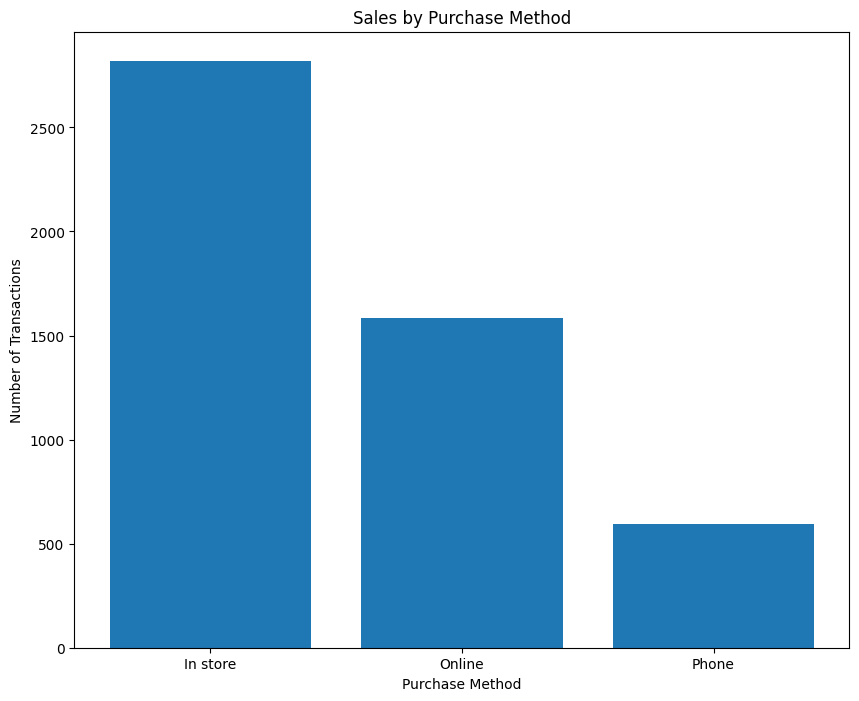

In [10]:
plt.figure(figsize=(10, 8))
plt.bar(purchase_method_df["Purchase Method"], purchase_method_df["Total Transactions"])

plt.title("Sales by Purchase Method")
plt.ylabel("Number of Transactions")
plt.xlabel("Purchase Method")

plt.show()